# ベースラインモデル

## 1.単純な未来予測

### 1_1.過去の平均値から予測する

In [63]:
import pandas as pd
import sys
sys.path.append("src")

from data_analitics import utils as util   # 例: my_module.py を読み込み

pd.options.mode.chained_assignment = None  # default='warn's

In [64]:
# データ取得
df = pd.read_csv('./data/jj.csv')

In [65]:
# データの確認
df.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


In [66]:
df.tail()

,date,data
79,1979-10-01,9.99
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-02,16.02
83,1980-10-01,11.61


In [67]:
# データセットを、訓練データセットとテストデータセットに分割
train = df[:-4]
test = df[-4:]

#### 1_1_1.過去の平均値に基づくベースラインを実装する

In [68]:
import numpy as np

In [69]:
# 訓練データセットのdata列の算術平均を計算
historical_mean = np.mean(train['data'])
print(historical_mean)
# 過去の平均値は4.31ドルとなる

4.308499987499999


In [70]:
# 訓練データセット全体の平均値を予測値として設定
test.loc[:, 'pred_mean'] = historical_mean

#### 平均絶対誤差: mean absolute Percentage Error

ベースラインの性能をテストデータセットで評価するには、誤差指標を定義して計算する必要がある。

In [71]:
# def mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
#     return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [72]:
# ベースラインモデルのMAPEを計算
mape_hist_mean =  util.mape(test['data'], test['pred_mean'])
print(f"ベースラインモデルのMAPE: {mape_hist_mean:.2f}%")

ベースラインモデルのMAPE: 70.01%


#### 1_1_2.予測値を可視化

In [73]:
import matplotlib.pyplot as plt

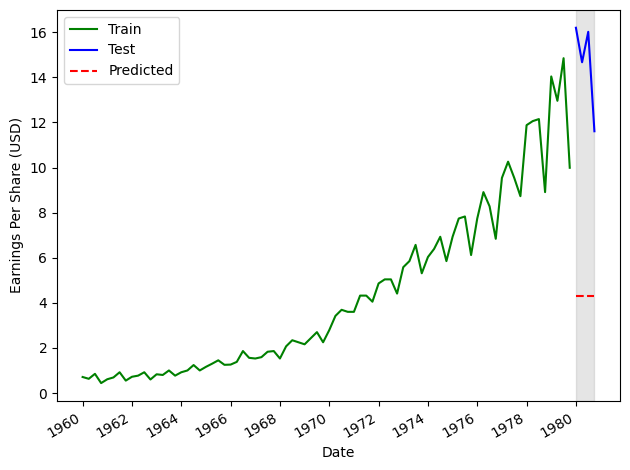

In [74]:
fig, ax = plt.subplots()

ax.plot(train['date'], train['data'], 'g-',label='Train')
ax.plot(test['date'], test['data'], 'b-',label='Test')
ax.plot(test['date'], test['pred_mean'], 'r--',label='Predicted')

ax.set_xlabel('Date')
ax.set_ylabel('Earnings Per Share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)   
ax.legend(loc=2)

plt.xticks(
    np.arange(0, 85, 8),
    [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980]
    )

fig.autofmt_xdate()
plt.tight_layout()

### 1_2.前年の平均値を予測する

データセットには正のトレンド成分があり、過去の値は長期的な未来の値を予測するための説明変数とは言えない。

In [75]:
# 訓練データセットの最後の４つのデータ点である、1979年の４つのEPSの平均を計算
last_year_mean = np.mean(train['data'][-4:])

print(last_year_mean)
# 1979年のEPSの平均は12.96ドルとなる


12.96


In [76]:
# 訓練データセット全体の平均値を予測値として設定
test.loc[:, 'pred__last_year_mean'] = last_year_mean
### 予測値を可視化

In [77]:
# MAPE
mape_last_year_mean = util.mape(test['data'], test['pred__last_year_mean'])
print(mape_last_year_mean)

15.5963680725103


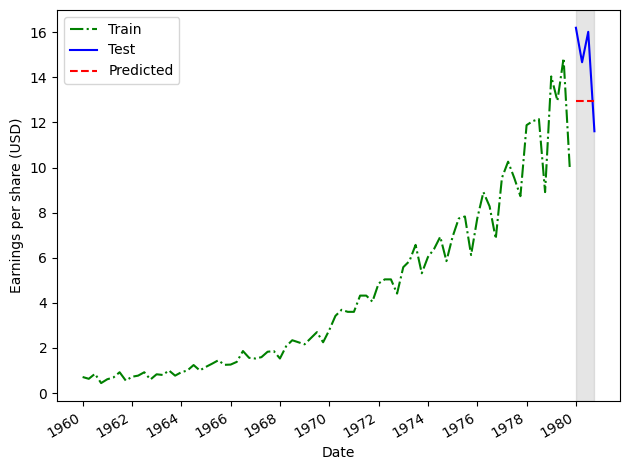

In [78]:
fig, ax = plt.subplots()

ax.plot(train['date'], train['data'], 'g-.', label='Train')
ax.plot(test['date'], test['data'], 'b-', label='Test')
ax.plot(test['date'], test['pred__last_year_mean'], 'r--', label='Predicted')

ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)
ax.legend(loc=2)

plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/1_2_trend.png', dpi=300)

### 1_3.最後の既知の値を使って予測する

In [79]:
last = train.data.iloc[-1]
print(last)

9.99


In [80]:
test.loc[:, 'pred_last'] = last

In [81]:
mape_last = util.mape(test['data'], test['pred_last'])
print(mape_last)

30.457277908606535


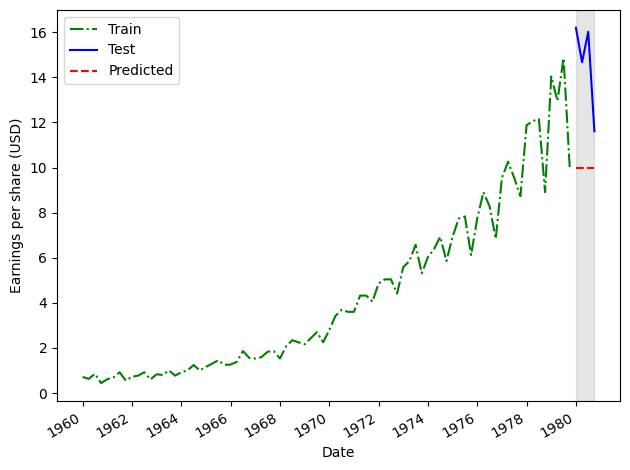

In [82]:
fig, ax = plt.subplots()

ax.plot(train['date'], train['data'], 'g-.', label='Train')
ax.plot(test['date'], test['data'], 'b-', label='Test')
ax.plot(test['date'], test['pred_last'], 'r--', label='Predicted')

ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)
ax.legend(loc=2)

plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

### 2.単純な季節予測を実装する

In [83]:
# 予測値は、訓練データセットの最後の４つのデータ点である。
test.loc[:, 'pred_last_season'] = train['data'][-4:].values

test

,date,data,pred_mean,pred__last_year_mean,pred_last,pred_last_season
80,1980-01-01,16.20,4.3085,12.96,9.99,14.04
81,1980-04-01,14.67,4.3085,12.96,9.99,12.96
82,1980-07-02,16.02,4.3085,12.96,9.99,14.85
83,1980-10-01,11.61,4.3085,12.96,9.99,9.99


In [84]:
# MAPE
mape_naive_seasonal = util.mape(test['data'], test['pred_last_season'])
print(mape_naive_seasonal)

11.561658552433654


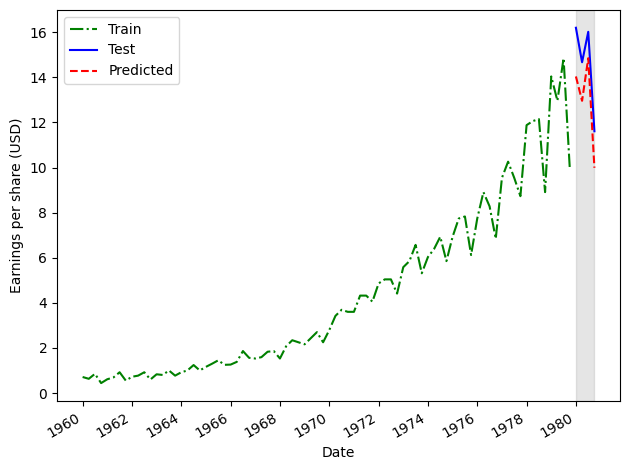

In [85]:
fig, ax = plt.subplots()

ax.plot(train['date'], train['data'], 'g-.', label='Train')
ax.plot(test['date'], test['data'], 'b-', label='Test')
ax.plot(test['date'], test['pred_last_season'], 'r--', label='Predicted')
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)
ax.legend(loc=2)

plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/1_3_seasonal.png', dpi=300)